In [81]:
!pip install gdown

In [82]:
gid_map = {
    'scalability': '1513474150',
    'optimality': '2117154112'
}

In [83]:
import gdown
import pandas as pd
import numpy as np
from scipy import stats

sheet_id = "1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI"

def get_pandas_from_gid(gid_name):
    # Replace with your actual Google Sheet ID
    # Optionally: specify the sheet/tab number (gid=0 for the first sheet)
    gid = gid_map[gid_name]
    
    # Construct export URL
    url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"
    
    # Set desired output filename
    output = f"{gid_name}.csv"
    
    # Download CSV using gdown
    gdown.download(url, output, quiet=False)
    original_df = pd.read_csv(output)
    return original_df

import pandas as pd
import numpy as np
from scipy import stats

def calculate_grouped_stats_and_ci(df: pd.DataFrame, 
                                   grouping_columns: list, 
                                   value_columns: list,  # Changed to a list
                                   confidence_level: float = 0.95) -> pd.DataFrame:
    """
    Groups a DataFrame by specified columns, calculates mean, count, standard deviation,
    and the confidence interval (using t-distribution) for multiple given value columns.

    Args:
        df (pd.DataFrame): The input Pandas DataFrame.
        grouping_columns (list): A list of column names to group the DataFrame by.
        value_columns (list): A list of column names for which to calculate the mean,
                              count, standard deviation, and confidence interval.
        confidence_level (float, optional): The desired confidence level (e.g., 0.95 for 95%).
                                            Defaults to 0.95.

    Returns:
        pd.DataFrame: A DataFrame containing the grouped results with 'Average', 'Count',
                      'Std_Dev', 'CI_Lower', and 'CI_Upper' columns for each value column.
    """
    
    # Check if all value_columns are numeric
    for col in value_columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            raise TypeError(f"The '{col}' in value_columns must be a numeric column.")

    # Create an aggregation dictionary for multiple value columns
    agg_dict = {col: ['mean', 'count', 'std'] for col in value_columns}
    
    # Group by the specified columns and aggregate
    grouped_df = df.groupby(grouping_columns).agg(agg_dict).reset_index()

    # Flatten MultiIndex columns and rename for clarity
    new_columns = []
    for col_pair in grouped_df.columns:
        if col_pair[1]: # If it's a multi-level column (e.g., ('Value', 'mean'))
            new_columns.append(f"{col_pair[0]}_{col_pair[1]}")
        else: # If it's a grouping column
            new_columns.append(col_pair[0])
    grouped_df.columns = new_columns

    # Rename suffixes for consistency
    rename_map = {}
    for col in value_columns:
        rename_map[f'{col}_mean'] = f'{col}_Average'
        rename_map[f'{col}_count'] = f'{col}_Count'
        rename_map[f'{col}_std'] = f'{col}_Std_Dev'
    grouped_df.rename(columns=rename_map, inplace=True)

    # Function to calculate confidence interval for a single row and a specific value column
    def calculate_ci_for_column_in_row(row, col_prefix, conf_level):
        avg = row.get(f'{col_prefix}_Average')
        count = row.get(f'{col_prefix}_Count')
        std_dev = row.get(f'{col_prefix}_Std_Dev')

        # Check for NaN values or insufficient data
        if pd.isna(avg) or pd.isna(count) or pd.isna(std_dev) or count < 2:
            return np.nan, np.nan
        
        # Degrees of freedom for t-distribution
        df_t = count - 1
        
        # Calculate standard error of the mean
        sem = std_dev / np.sqrt(count)
        
        # Calculate confidence interval
        lower, upper = stats.t.interval(conf_level, df_t, loc=avg, scale=sem)
        return lower, upper

    # Apply the confidence interval calculation for each value column
    for col in value_columns:
        grouped_df[[f'{col}_CI_Lower', f'{col}_CI_Upper']] = grouped_df.apply(
            lambda row: calculate_ci_for_column_in_row(row, col, confidence_level),
            axis=1,
            result_type='expand'
        )
    
    return grouped_df

In [122]:
optimality_df = get_pandas_from_gid('optimality')
optimality_df.loc[optimality_df['Objective Function'] == 'triangledensestsubgraph', 'Cost Best Solution'] = optimality_df.loc[optimality_df['Objective Function'] == 'triangledensestsubgraph', 'Cost Best Solution'] / 3
optimality_df

/home/viniciusvdias/miniconda3/lib/python3.11/site-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1WUywPr_TxlUfPGVyMF0I2ALxXiHAyknKoZ3X13kKrUI/export?format=csv&gid=2117154112
To: /home/viniciusvdias/repos/fractal-private/plots/optimality.csv
2.44MB [00:00, 9.07MB/s]


,Graph Name,Initial Vertices,Initial Solutions,Timeout (ms),Objective Function,Threads,Repetition,Total Time (ms),Time to Best Solution (ms),Effective Runs,Cost Best Solution,Vertices,Edges,Best Solution
0,dblp,10,10000,3000,triangledensestsubgraph,32,5,1016545,968000.0,9270,13585.000000,287,41041,"vsub(nvertices=287,nedges=41041,vertices={2411..."
1,dblp,10,10000,3000,triangledensestsubgraph,32,3,1049310,970000.0,9270,13585.000000,287,41041,"vsub(nvertices=287,nedges=41041,vertices={2411..."
2,dblp,10,10000,3000,triangledensestsubgraph,32,2,1032253,975000.0,9270,13395.333333,285,40470,"vsub(nvertices=285,nedges=40470,vertices={2411..."
3,dblp,10,10000,3000,triangledensestsubgraph,32,1,1130407,977000.0,9270,13395.333333,285,40470,"vsub(nvertices=285,nedges=40470,vertices={2411..."
4,dblp,10,10000,3000,triangledensestsubgraph,32,4,1035539,973000.0,9270,13207.000000,283,39903,"vsub(nvertices=283,nedges=39903,vertices={2411..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1600,dblp,10,10000,2000,labelentropy,32,1,583650,0.0,9270,0.000000,10,13,"vsub(nvertices=10,nedges=13,vertices={2391021,..."
1601,dblp,10,10000,3000,labelentropy,32,2,874003,0.0,9270,0.000000,10,13,"vsub(nvertices=10,nedges=13,vertices={2391021,..."
1602,dblp,10,10000,2000,labelentropy,32,3,583847,0.0,9270,0.000000,10,13,"vsub(nvertices=10,nedges=13,vertices={2391021,..."
1603,dblp,10,10000,3000,labelentropy,32,5,873981,0.0,9270,0.000000,10,13,"vsub(nvertices=10,nedges=13,vertices={2391021,..."


In [123]:
grouping_columns = ["Graph Name", "Objective Function", "Initial Vertices", "Initial Solutions", "Threads"]
value_column = ["Cost Best Solution", "Total Time (ms)"]
grouped_df = calculate_grouped_stats_and_ci(optimality_df, grouping_columns, value_column)
grouped_df

/home/viniciusvdias/miniconda3/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/viniciusvdias/miniconda3/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,Graph Name,Objective Function,Initial Vertices,Initial Solutions,Threads,Cost Best Solution_Average,Cost Best Solution_Count,Cost Best Solution_Std_Dev,Total Time (ms)_Average,Total Time (ms)_Count,Total Time (ms)_Std_Dev,Cost Best Solution_CI_Lower,Cost Best Solution_CI_Upper,Total Time (ms)_CI_Lower,Total Time (ms)_CI_Upper
0,citeseer,conductance,10,10,32,0.995744,15,0.006760,16778.933333,15,6756.806235,0.992001,0.999488,13037.138761,20520.727906
1,citeseer,conductance,10,100,32,0.993018,15,0.007643,4892.400000,15,2235.700044,0.988785,0.997250,3654.310583,6130.489417
2,citeseer,conductance,10,1000,32,1.000000,15,0.000000,36203.666667,15,15373.670394,NaN,NaN,27690.011776,44717.321557
3,citeseer,conductance,10,10000,32,1.000000,15,0.000000,368387.466667,15,156693.172510,NaN,NaN,281613.680042,455161.253292
4,citeseer,degreeentropy,10,100,32,4.208491,15,0.003056,4230.333333,15,1691.448900,4.206799,4.210184,3293.640154,5167.026513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,youtube,modularity,10,1000,32,0.001888,15,0.000416,62694.733333,15,26302.164616,0.001658,0.002119,48129.080066,77260.386601
103,youtube,triangledensestsubgraph,10,10,32,62.922840,15,3.090019,20735.133333,15,8511.065158,61.211644,64.634035,16021.862550,25448.404117
104,youtube,triangledensestsubgraph,10,100,32,66.463364,15,13.559046,7802.800000,15,3232.730960,58.954614,73.972113,6012.573266,9593.026734
105,youtube,triangledensestsubgraph,10,1000,32,101.483329,15,13.934195,66530.800000,15,27566.904337,93.766829,109.199829,51264.757220,81796.842780


In [145]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_average_by_group_and_initial_solutions(df: pd.DataFrame, grouping_columns: list, baseline_scores: dict, title: str, log_scale: bool = False):
    """
    Generates a Matplotlib bar plot showing 'Average' performance with confidence intervals
    as error bars. The x-axis represents combined experimental groups, and 'Initial Solutions'
    is used for the legend (differentiating bars within each group).

    Args:
        df (pd.DataFrame): The input DataFrame containing experimental results.
                           Expected columns: 'Graph Name', 'Objective Function',
                           'Initial Vertices', 'Timeout (ms)', 'Threads',
                           'Initial Solutions', 'Average', 'CI_Lower', 'CI_Upper'.
        grouping_columns (list): A list of column names that define the unique
                                 experimental groups for the X-axis (excluding 'Initial Solutions').
    """

    axis_fontsize = 26
    axis_title_fontsize = 26
    title_fontsize = 26
    legend_fontsize = 24

    # Sort for consistent plotting: first by grouping_columns, then by Initial Solutions
    df = df.sort_values(by=grouping_columns + ['Initial Solutions'])

    plt.figure(figsize=(13, 8)) # Adjust figure size for potentially more x-axis labels

    # Get unique 'Initial Solutions' for legend and bar differentiation
    unique_initial_solutions = sorted(df['Initial Solutions'].unique())
    num_initial_solutions = len(unique_initial_solutions)

    # Calculate the number of distinct groups for the X-axis
    # Create a string representation for each group for x-axis labels
    df['Group_Label'] = df[grouping_columns].apply(
        lambda row: " | ".join([f"{row[col]}" for col in grouping_columns]), axis=1
    )
    unique_groups = df['Group_Label'].unique()
    x_axis_positions = np.arange(len(unique_groups)) # Numerical positions for each group

    # Define bar width and spacing
    bar_width = 0.8 / (num_initial_solutions+1) if num_initial_solutions > 0 else 0.8
    
    # Generate a distinct color for each 'Initial Solution' value
    colors = plt.get_cmap('Pastel1', num_initial_solutions + len(baseline_scores))
    hatches = ['/', '\\', '|', '-', '+', 'x', 'o', '.', '*']
    
    # Iterate through each unique 'Initial Solution' value to plot its bars
    for i, solution_count in enumerate(unique_initial_solutions):
        # Filter data for the current 'Initial Solution' count
        subset_df = df[df['Initial Solutions'] == solution_count].copy()
        
        # Merge with all unique groups to ensure all x-axis positions are covered, even if no data
        full_x_data = pd.DataFrame({'Group_Label': unique_groups})
        subset_df = pd.merge(full_x_data, subset_df, on='Group_Label', how='left')
        
        # Sort again to match the order of x_axis_positions
        subset_df = subset_df.set_index('Group_Label').loc[unique_groups].reset_index()

        # Calculate the x-position for bars of this 'Initial Solution' count
        offset = (i - (num_initial_solutions+len(baseline_scores)) / 2 + 0.5) * bar_width
        x_positions_for_bars = x_axis_positions + offset
        
        # Calculate error bars
        yerr_lower = subset_df['Cost Best Solution_Average'] - subset_df['Cost Best Solution_CI_Lower']
        yerr_upper = subset_df['Cost Best Solution_CI_Upper'] - subset_df['Cost Best Solution_Average']

        # Plot the bars
        plt.bar(
            x_positions_for_bars,
            subset_df['Cost Best Solution_Average'],
            yerr=[yerr_lower, yerr_upper],
            width=bar_width,
            capsize=5,
            label=f'Initial Solutions: {int(solution_count)}', # Label for the legend
            color=colors(i),
            hatch=hatches[i],
            edgecolor='black',
            linewidth=1.5,
            error_kw=dict(lw=1.5, capsize=5, capthick=1.5)
        )

    i = 0
    for baseline, baseline_values in baseline_scores.items():
        offset = ((num_initial_solutions + i) - (num_initial_solutions+len(baseline_scores)) / 2 + 0.5) * bar_width
        x_positions_for_bars = x_axis_positions + offset
        # Plot the bars
        plt.bar(
            x_positions_for_bars,
            baseline_values,
            width=bar_width,
            capsize=5,
            label=baseline, # Label for the legend
            color=colors(num_initial_solutions + i),
            hatch=hatches[num_initial_solutions + i],
            edgecolor='black',
            linewidth=1.5,
            error_kw=dict(lw=1.5, capsize=5, capthick=1.5)
        )
        i += 1



    #plt.xlabel('Experimental Group Configuration', fontsize=15) # X-axis label with group name
    ylabel = 'Average Best Score'
    if log_scale:
        plt.yscale('log')
        ylabel += ' (log-scale)'
    plt.ylabel(ylabel, fontsize=axis_title_fontsize)
    
    plt.xticks(x_axis_positions, unique_groups, rotation=0, ha='center', fontsize=axis_fontsize)
    plt.yticks(fontsize=axis_fontsize)
    
    plt.grid(True, linestyle='--', alpha=0.7, which="major", axis='y')
    plt.grid(False, axis='x')

    # Place legend outside the plot area, with title for initial solutions
    plt.legend(loc='best', borderaxespad=0., fontsize=legend_fontsize)
    plt.tight_layout()
    plt.savefig(title.replace(' ','_') + '.pdf')
    plt.show()

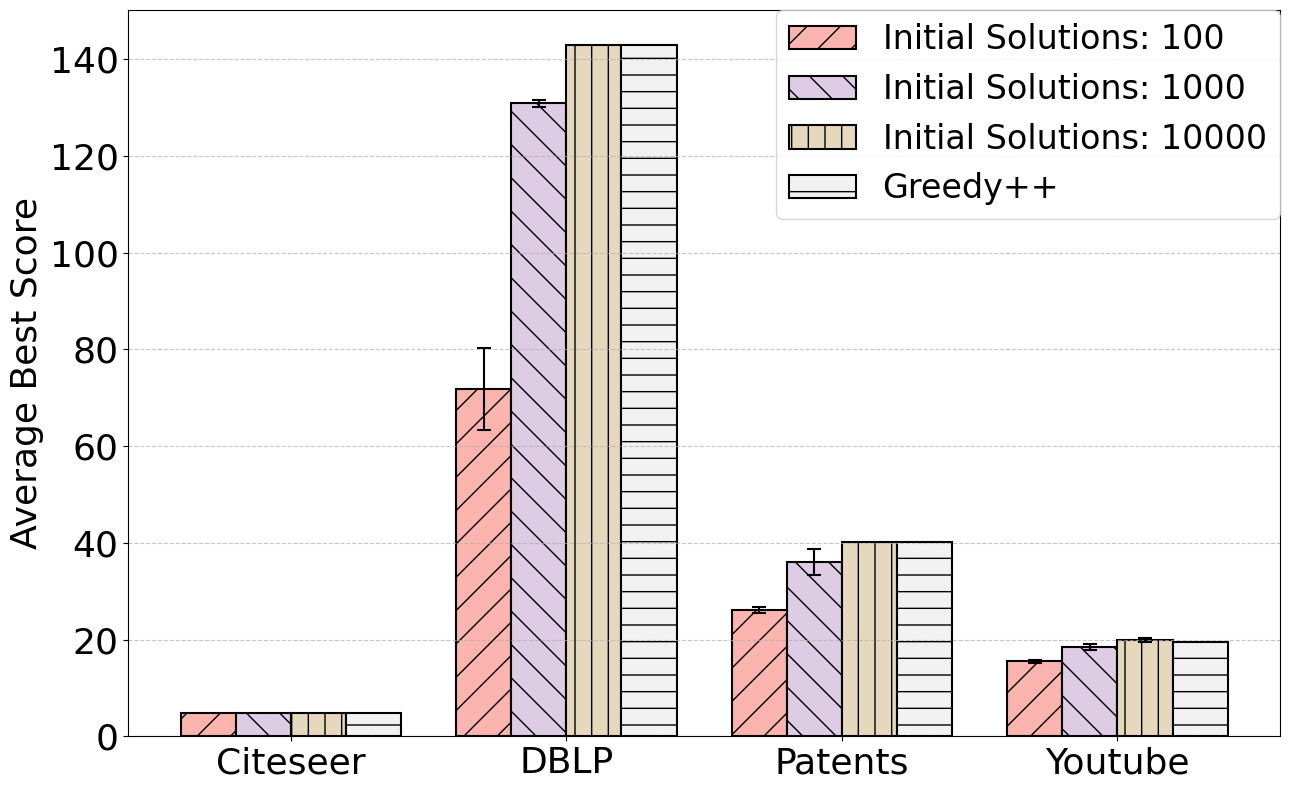

In [146]:
grouping_cols = ["Graph Name"]
df = grouped_df[(grouped_df["Objective Function"] == "densesubgraph") & (grouped_df['Graph Name'].isin(['citeseer', 'dblp', 'patents', 'youtube'])) & (grouped_df['Initial Solutions'] > 32)].copy()
df['Graph Name'] = df['Graph Name'].replace({
    'citeseer': 'Citeseer',
    'dblp': 'DBLP',
    'patents': 'Patents',
    'youtube': 'Youtube',
})
plot_average_by_group_and_initial_solutions(df, grouping_cols, {'Greedy++': [4.905,143,40.129,19.389]}, title="Optimality Dense Subgraph")

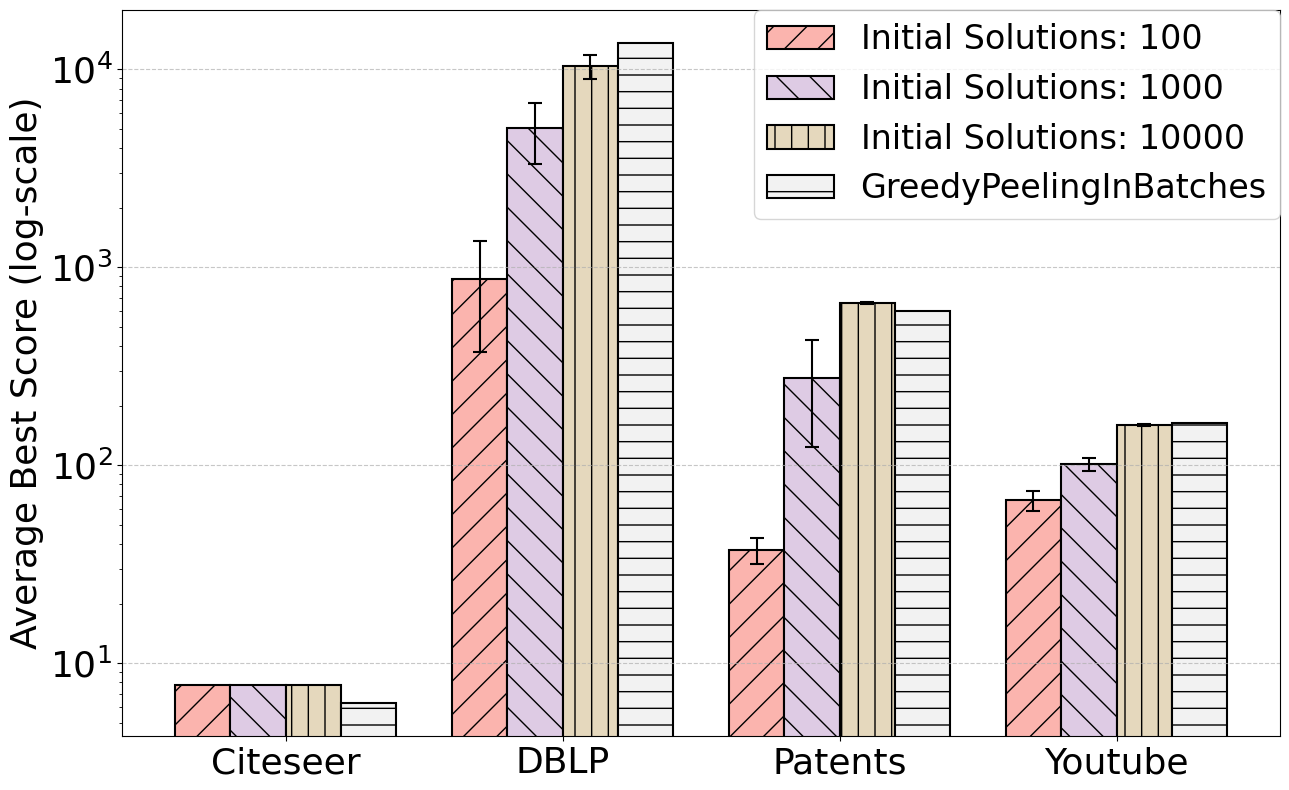

In [147]:
grouping_cols = ["Graph Name"]
df = grouped_df[(grouped_df["Objective Function"] == "triangledensestsubgraph") & (grouped_df['Graph Name'].isin(['citeseer', 'dblp', 'patents', 'youtube'])) & (grouped_df['Initial Solutions'] > 32)].copy()
df['Graph Name'] = df['Graph Name'].replace({
    'citeseer': 'Citeseer',
    'dblp': 'DBLP',
    'patents': 'Patents',
    'youtube': 'Youtube',
})
plot_average_by_group_and_initial_solutions(df, grouping_cols, {'GreedyPeelingInBatches': [6.272727273,13585,599.8496241,164.1794872]}, title="Optimality Triangle Densest Subgraph", log_scale=True)